### 🧠 Neural Networks: Traditional vs. CNN

| Feature | Traditional Neural Networks | Convolutional Neural Networks (CNNs) |
| :--- | :--- | :--- |
| **How they "see"** | Very rigid; can only read data in a single straight line (1D arrays). | Built to process 2D grids; looks at images the way human eyes do. |
| **Spatial Awareness** | Poor. Requires "flattening" the image, which destroys the shape and structure. | Excellent. Keeps the image grid intact, preserving "up, down, left, right." |

### ⚙️ The Mechanics of a CNN

> *Instead of forcing every neuron to look at the entire image at the exact same time, a CNN uses tiny **"filters"** (like magnifying glasses).*

**1. The Process**
A small filter (e.g., a 3x3 square of pixels) slides across the image, scanning it sequentially from top-left to bottom-right.

**2. The Purpose**
Instead of processing the entire picture at once, the filter focuses solely on finding one specific feature in that small window—such as a vertical edge, a curve, or a specific patch of color.

### 🤝 Parameter Sharing (The Magic of CNNs)

If a CNN learns that a specific filter is really good at finding the edge of a cat's ear in the top-left corner of an image, it uses the **exact same filter** to scan for cat ears across the rest of the image.

**The Result:** Because it reuses the filter, the CNN requires only a fraction of the parameters that a standard neural network needs. 
* ⚡ **Fast:** Requires significantly less computing power.
* 🎯 **Accurate:** Remarkably good at finding patterns no matter where they are in the image.

In [42]:
%load_ext autoreload
%autoreload 2

import os, sysconfig
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "4"  # opreste ceva mesaje de warning

# Sistemul are CUDA 13.2 care nu mai suporta CC 6.1 (Pascal/GTX 1050 Ti).
# Indicam XLA + PATH catre ptxas-ul din venv (CUDA 12.3) care suporta CC 6.1.
_nvcc = os.path.join(sysconfig.get_paths()["purelib"], "nvidia", "cuda_nvcc")
os.environ["PATH"] = os.path.join(_nvcc, "bin") + os.pathsep + os.environ.get("PATH", "")
os.environ["XLA_FLAGS"] = f"--xla_gpu_cuda_data_dir={_nvcc}"

import tensorflow as tf

# Memory growth in loc de a aloca toata memoria GPU dintr-o data
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)

import helpers
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 📊 Dataset: CIFAR-10

In the code below, we load the dataset and **normalize** the pixel values (converting them from a scale of 0-255 down to a scale of 0.0-1.0).

**Why do we do this?**
Because neural networks learn much faster and more reliably when dealing with small, uniform numbers. 

* ⚡ **Speed:** If we feed the network large numbers (like 255), the internal math gets messy and training slows to a crawl.
* ⚖️ **Stability:** Keeping the inputs between 0 and 1 stops the parameters from swinging wildly out of control, giving the network an easy path to learn the features of the image.

In [43]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### 👁️ Verify the Data

To verify that the dataset loaded correctly and the images match their labels, we will plot the first 25 images from the training set and display the corresponding class name above each image:

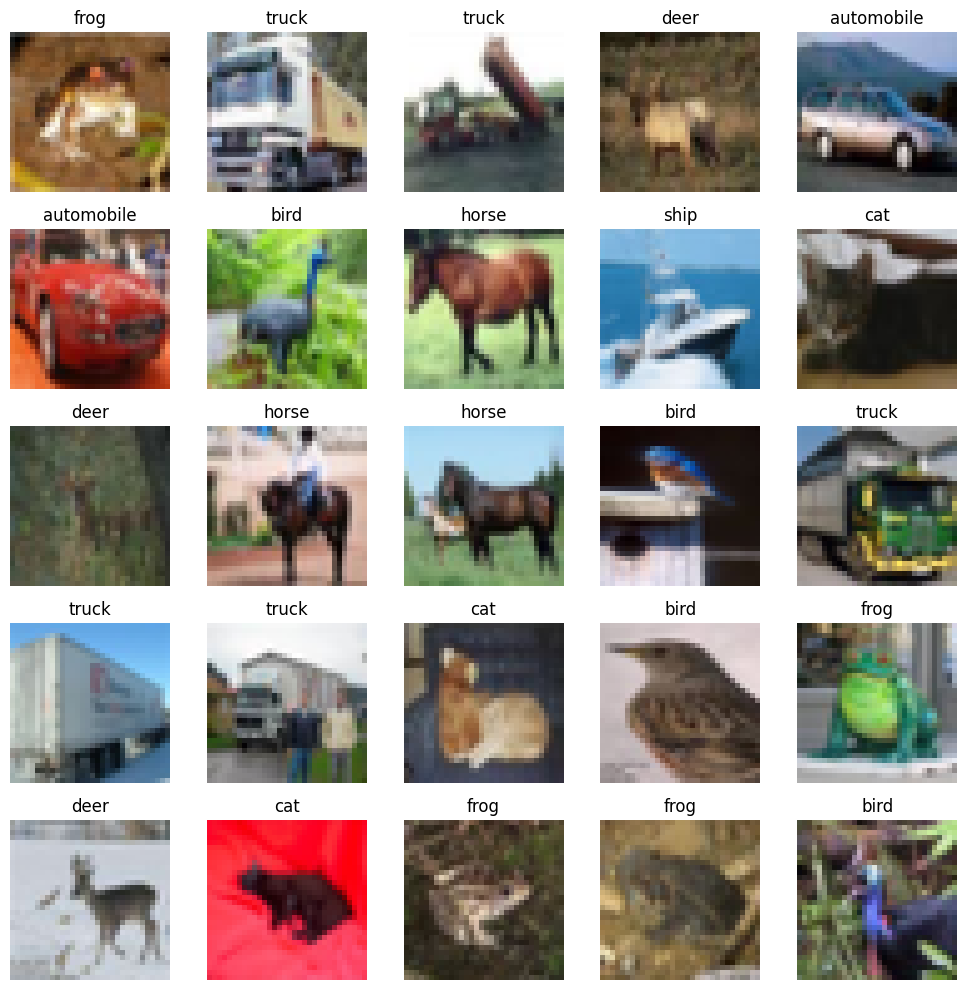

In [44]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

helpers.show_dataset(train_images, train_labels, class_names)

### 📥 How the Image Enters the CNN

**1. The Convolutional Base (The Feature Extractor)**
The image is fed first into the convolutional base. This section acts as a dedicated feature extractor. It looks at the raw image and finds all the important patterns (edges, circles, colors).



**2. The Layers: Conv2D and MaxPooling2D**
The code uses an alternating stack of these two specific layers:
* 🕵️‍♂️ **`Conv2D` (The Detective):** This is the "magnifying glass." It slides a 2D filter over the image to find specific features like cat ears and tires.
* 🗜️ **`MaxPooling2D` (The Summarizer):** After the `Conv2D` finds a bunch of features, the image grid contains a lot of unnecessary data. The `MaxPooling2D` layer steps in and shrinks the image grid down, keeping only the "loudest," most important features. This saves a massive amount of computing power.

**3. Understanding the Input Shape: `(32, 32, 3)`**
Color images are 3D data blocks (called tensors). We must tell the very first layer exactly what size block to expect:
* ↕️ **Height:** 32 pixels
* ↔️ **Width:** 32 pixels
* 🎨 **Color Channels:** 3 (Red, Green, Blue)

In [45]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu')
])

cnn_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

### 🧠 Adding the Dense Layers (The Decision Makers)

To complete the model, we need to take all the features our CNN found and make a final decision: *What is this a picture of?* To do this, we use **Dense layers** (these are just traditional neural network layers). But we have a major problem: our CNN outputs a 3D block of data, and as we learned earlier, traditional networks can only read 1D straight lines!

**The Code Breakdown:**

* 🥞 **`model.add(layers.Flatten())`**
  This solves our 3D problem. The last output from our CNN was a tiny, thick block of features shaped as `(4, 4, 64)`. The `Flatten` layer literally unrolls this 3D block into one single, 1D straight line of 1,024 numbers.
  
* ⚖️ **`model.add(layers.Dense(64, activation='relu'))`**
  Now that the data is in a straight line, we feed it into a standard hidden layer with 64 neurons. Think of these 64 neurons as the judge looking at all the flattened clues and weighing the evidence. *(Note: `relu` is just a math filter that helps the network learn faster by turning any negative numbers into zeros).*
  
* 📢 **`model.add(layers.Dense(10))`**
  This is the final output layer. It has exactly **10 neurons** because the CIFAR-10 dataset has exactly 10 categories (airplane, dog, cat, etc.). The neuron that outputs the highest number is the network's final guess!

In [46]:
cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(64, activation='relu'))
cnn_model.add(layers.Dense(10))
cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### 🎓 Compiling and Training 

Before a network can learn, we have to give it a syllabus and a grading rubric. Then, we force it to study. 

**1. `model.compile(...)`: Setting the Rules**
This step doesn't train the model; it just equips the model with the tools it needs to learn.
* 🛠️ **`optimizer='adam'` (The Tuner):** This is the algorithm that decides *how* to adjust the millions of parameters when the network makes a mistake. 
* ❌ **`loss=...` (The Red Pen):** This calculates exactly how wrong the network's guesses are. The optimizer uses this "error score" to know which parameters to modify.
* 💯 **`metrics=['accuracy']` (The Grade):** This tells the network we want to track the simple percentage of images it guesses correctly.

**2. `model.fit(...)`: The Actual Studying**
This is where the math happens and the network looks at the images.
* 📚 **`epochs=10`:** An "epoch" is one complete pass through the entire dataset. Setting this to 10 means the network will look through the entire "textbook" of images 10 times to memorize the patterns.
* 📝 **`validation_data=...` (The Quiz):** After every single epoch, we test the network on a separate pile of images it has **never seen before**. This proves the network is actually learning what a "cat" looks like, rather than just memorizing the specific cat photos from the textbook.

In [47]:
cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

naive_cnn_model = cnn_model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/10
 23/391 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1418 - loss: 2.2844

I0000 00:00:1777363859.123443   13956 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3146 - loss: 1.8674

I0000 00:00:1777363863.618565   13957 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3988 - loss: 1.6468 - val_accuracy: 0.5106 - val_loss: 1.3765
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5283 - loss: 1.3191 - val_accuracy: 0.5532 - val_loss: 1.2397
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5877 - loss: 1.1698 - val_accuracy: 0.5898 - val_loss: 1.1598
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6270 - loss: 1.0598 - val_accuracy: 0.6251 - val_loss: 1.0662
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6568 - loss: 0.9846 - val_accuracy: 0.6595 - val_loss: 0.9822
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6830 - loss: 0.9130 - val_accuracy: 0.6768 - val_loss: 0.9319
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6969 - loss: 0.8734 - val_accuracy: 0.6700 - val_loss: 0.9296
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7150 - loss: 0.8199 - val_accuracy: 0.6863 - val

### 📈 Evaluating the Model: The Learning Curves

The graph below plots our model's accuracy over the 10 epochs. 

* 🔵 **The Blue Line (Training Accuracy):** This shows how well the model is performing on the data it is actively studying. 
* 🟠 **The Orange Line (Validation Accuracy):** This shows how well the model performs on brand-new, unseen data (the quiz).

**⚠️ The "Overfitting" Check:**
Notice how the blue line keeps going up, but the orange line starts to flatten out around 70%? This is a classic sign of slight **overfitting**. The model is starting to memorize the specific training images instead of learning general patterns. If we trained it for 50 epochs, the blue line would hit 100%, but the orange line might actually go down!

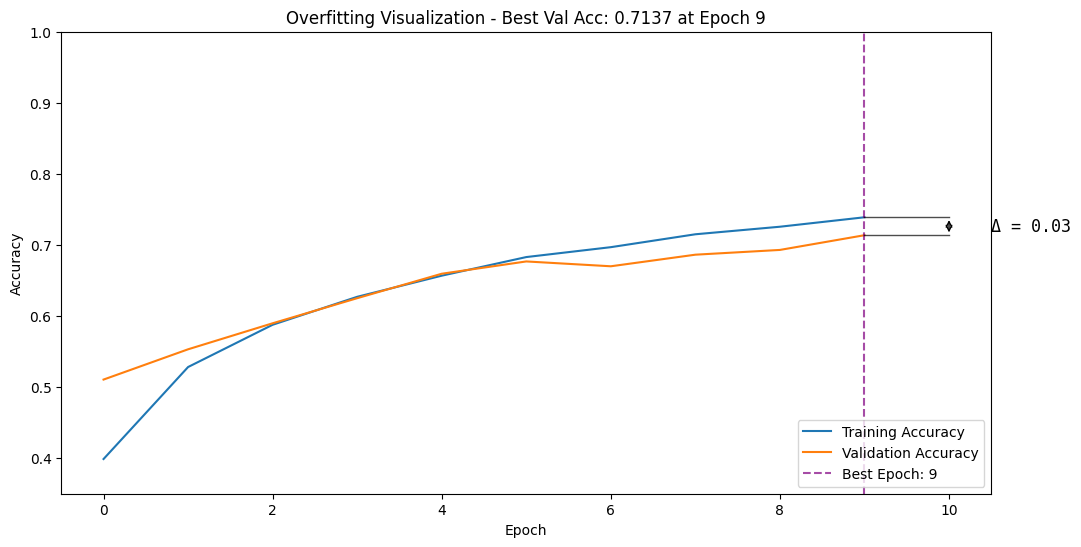

In [48]:
train_acc = naive_cnn_model.history['accuracy']
val_acc = naive_cnn_model.history['val_accuracy']
helpers.plot_overfitting(train_acc, val_acc)

### 🧩 The Confusion Matrix: Where is the model making mistakes?

An overall accuracy of 70% is helpful, but we need to know exactly *where* the model is failing. A **Confusion Matrix** lays out all the predictions on a grid. 
* The **rows** represent what the image *actually* was.
* The **columns** represent what the model *guessed* it was.

By looking at this grid, we can see if the network has a hard time telling the difference between specific classes (like cats and dogs, or automobiles and trucks).

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    airplane       0.72      0.77      0.75      1000
  automobile       0.75      0.87      0.81      1000
        bird       0.62      0.60      0.61      1000
         cat       0.58      0.50      0.54      1000
        deer       0.70      0.64      0.67      1000
         dog       0.67      0.60      0.63      1000
        frog       0.76      0.79      0.78      1000
       horse       0.69      0.78      0.74      1000
        ship       0.82      0.80      0.81      1000
       truck       0.77      0.78      0.77      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



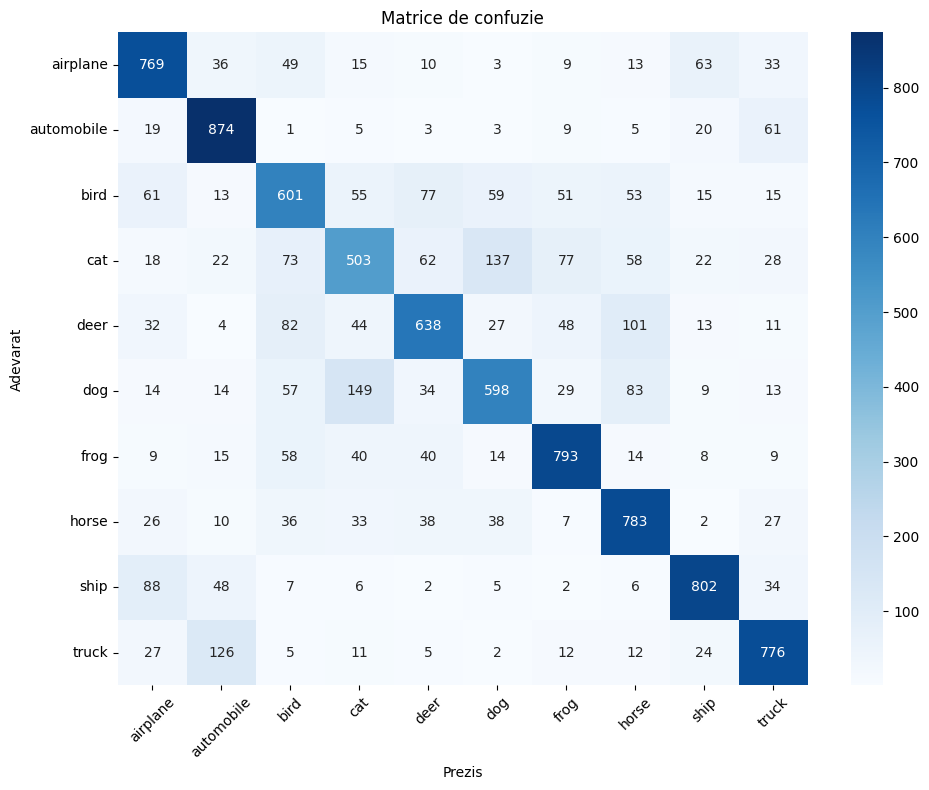

In [49]:
helpers.plot_confusion_matrix(cnn_model, test_images, test_labels, class_names)

### 🛡️ Fixing Overfitting with "Dropout"

Right now, the gap between our training accuracy (~80%) and validation accuracy (~70%) tells us the model is **overfitting**. It is memorizing the specific training images rather than learning general concepts. 

To fix this, we will add a **Dropout** layer.

**How Dropout Works:**
Imagine a group project where one really smart student does 100% of the work. If that student gets sick on presentation day, the whole group fails. 

A Dropout layer acts like a strict teacher who randomly sends 50% of the students out of the room every single day of the project. To survive, *every* student is forced to learn the material, and the group becomes incredibly resilient. 

In our CNN, `Dropout(0.5)` randomly turns off 50% of the neurons during each training step. This prevents the network from relying too heavily on any single path or specific pixel, forcing it to learn robust, general patterns.

In [73]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    # convolutional base
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    # classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # dropout layer
    layers.Dropout(0.5),
    layers.Dense(10)
])

cnn_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

dropout_cnn_model = cnn_model.fit(
    train_images,
    train_labels,
    epochs=10,
    # batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3999 - loss: 1.6380 - val_accuracy: 0.5141 - val_loss: 1.3315
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5326 - loss: 1.3109 - val_accuracy: 0.6026 - val_loss: 1.0859
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5892 - loss: 1.1642 - val_accuracy: 0.6370 - val_loss: 1.0200
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6264 - loss: 1.0784 - val_accuracy: 0.6500 - val_loss: 1.0071
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6519 - loss: 1.0058 - val_accuracy: 0.6697 - val_loss: 0.9334
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6706 - loss: 0.9491 - val_accuracy: 0.6946 - val_loss: 0.8806
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6871 - loss: 0.9010 - val_accuracy: 0.6955 - val_loss: 0.8708
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7005 - loss: 0.8667 -

### 📉 The Impact of Dropout: Overfitting Cured

By adding the Dropout layer, we fundamentally changed how the model learns, and the graph proves it was successful. 

* 👯 **The Lines are Hugging:** In our first model, the training accuracy (blue line) shot up to nearly 80% while the validation accuracy (orange line) stalled at 70%. Now,  the two lines are very close to each other. 
* 🧠 **Generalization over Memorization:** Because we randomly forced neurons to turn off during training, the network couldn't just memorize the specific training images. It was forced to learn true, generalized patterns. 

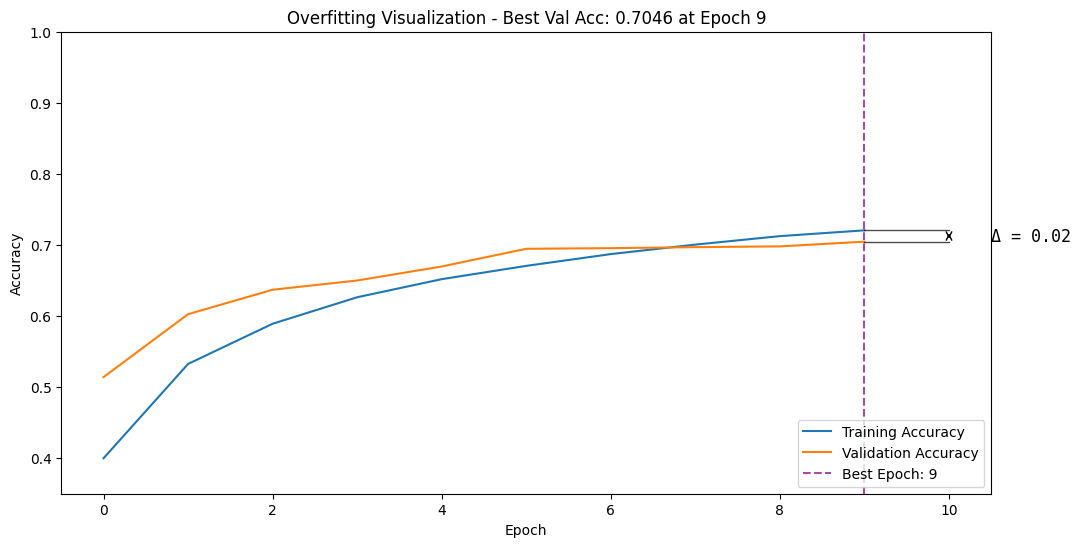

In [75]:
train_acc = dropout_cnn_model.history['accuracy']
val_acc = dropout_cnn_model.history['val_accuracy']
helpers.plot_overfitting(train_acc, val_acc)

### 🕵️‍♂️ Analyzing the Confusion Matrix

The overall accuracy is solid, but this matrix reveals exactly what the model "sees" and where its blind spots are. 

* ✅ **The Strongest Performers:** Look at the dark blue diagonal line. The model is incredibly confident at identifying **Automobiles (810 correct)**, **Frogs (791 correct)**, and **Ships (797 correct)**. These classes likely have very distinct shapes and background colors.
* ❌ **The Animal Mix-Ups:** The model really struggles with similar animals. If you look at the `cat` row, you'll see the model incorrectly guessed it was a `dog` **194 times**. It also frequently confused birds with deer (174 times). 
* 🚗 **The Vehicle Mix-Ups:** Interestingly, while it doesn't confuse vehicles with animals, it does struggle with similar vehicles. It looked at a `truck` and incorrectly guessed `automobile` **55 times**.

**Conclusion:** The Convolutional Neural Network is doing a great job separating broad categories (animals vs. vehicles), but it needs either more data or a more complex architecture to distinguish the fine-grained details between a cat and a dog.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    airplane       0.73      0.76      0.74      1000
  automobile       0.86      0.84      0.85      1000
        bird       0.64      0.57      0.60      1000
         cat       0.46      0.58      0.51      1000
        deer       0.71      0.61      0.66      1000
         dog       0.57      0.64      0.61      1000
        frog       0.87      0.64      0.74      1000
       horse       0.73      0.76      0.74      1000
        ship       0.75      0.89      0.81      1000
       truck       0.86      0.76      0.81      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.71     10000
weighted avg       0.72      0.70      0.71     10000



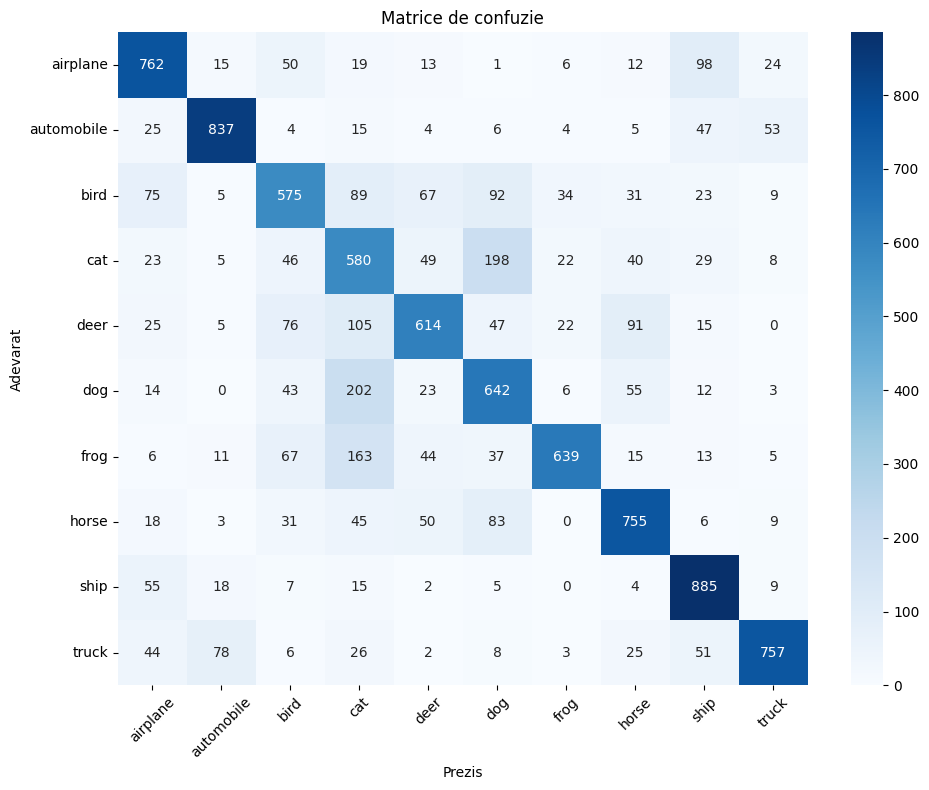

In [76]:
helpers.plot_confusion_matrix(cnn_model, test_images, test_labels, class_names)

as you can see now that we added the dropout layer, even though we dont see overfitting anymore, we can see something else; at epoch 10 val_accuracy goes down, it's worse than before. why is that?

we have to look at how the structure of the network changed. the dropout value currently is set to 0.5, that is "drop half of the neurons every run", in other terms, it sees HALF the network 10 times (as many times as the naive model)

we can do 2 things from here; 1. increase the number of epochs to 20-25 and 2. lower the dropout value to 0.3 or even 0.2 (0.5 for a cnn this small and for a dataset this simplistic is quite agressive anyway)

let's try increasing the epoch count first

In [77]:
dropout_ec20_cnn_model = cnn_model.fit(
    train_images,
    train_labels,
    epochs=20,
    # batch_size=128,
    validation_data=(test_images, test_labels),
)
dropout_ec25_cnn_model = cnn_model.fit(
    train_images,
    train_labels,
    epochs=25,
    # batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7299 - loss: 0.7704 - val_accuracy: 0.6988 - val_loss: 0.8808
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7399 - loss: 0.7470 - val_accuracy: 0.7077 - val_loss: 0.8626
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7447 - loss: 0.7285 - val_accuracy: 0.7112 - val_loss: 0.8452
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7525 - loss: 0.7023 - val_accuracy: 0.7158 - val_loss: 0.8776
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7560 - loss: 0.6909 - val_accuracy: 0.7159 - val_loss: 0.8777
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7635 - loss: 0.6671 - val_accuracy: 0.7193 - val_loss: 0.8434
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7681 - loss: 0.6551 - val_accuracy: 0.7165 - val_loss: 0.8773
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7710 - loss: 0.6445 - 

so in my infinite wisdom i thought that fitting the model and returning the history object re-trains the entire model from scratch. 

it doesnt.

instead it continues where it left off. but this is also interesting to see because it essentially kept improving until it flattened out (probably, from the numbers but it'll be clearer once we look at the plots)

also i think it started overfitting again?

let's see

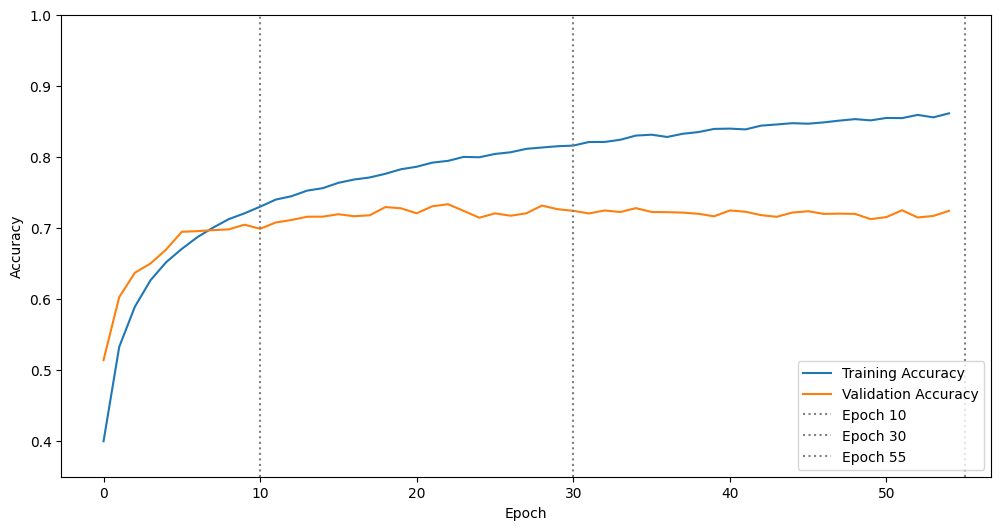

In [78]:
# we're gonna plot the accuracy over all the epochs compared to the val_accuracy score to see if we can spot overfitting

train_acc = (dropout_cnn_model.history['accuracy'] +
             dropout_ec20_cnn_model.history['accuracy'] + 
             dropout_ec25_cnn_model.history['accuracy'])

val_acc = (dropout_cnn_model.history['val_accuracy'] +
           dropout_ec20_cnn_model.history['val_accuracy'] +
           dropout_ec25_cnn_model.history['val_accuracy'])

n1 = len(dropout_cnn_model.history['accuracy'])
n2 = n1 + len(dropout_ec20_cnn_model.history['accuracy'])
n3 = n2 + len(dropout_ec25_cnn_model.history['accuracy'])

plt.figure(figsize=(12, 6))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=n1, color='gray', linestyle=':', label=f'Epoch {n1}')
plt.axvline(x=n2, color='gray', linestyle=':', label=f'Epoch {n2}')
plt.axvline(x=n3, color='gray', linestyle=':', label=f'Epoch {n3}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.35, 1])
plt.legend(loc='lower right')
plt.show()

clearly overfitting in the end, but it wasn't really useless as we can observe the point it started "sa mearga pe campii" (haha so funny), as well as the theoretical best validation accuracy achieved (at epoch 29)

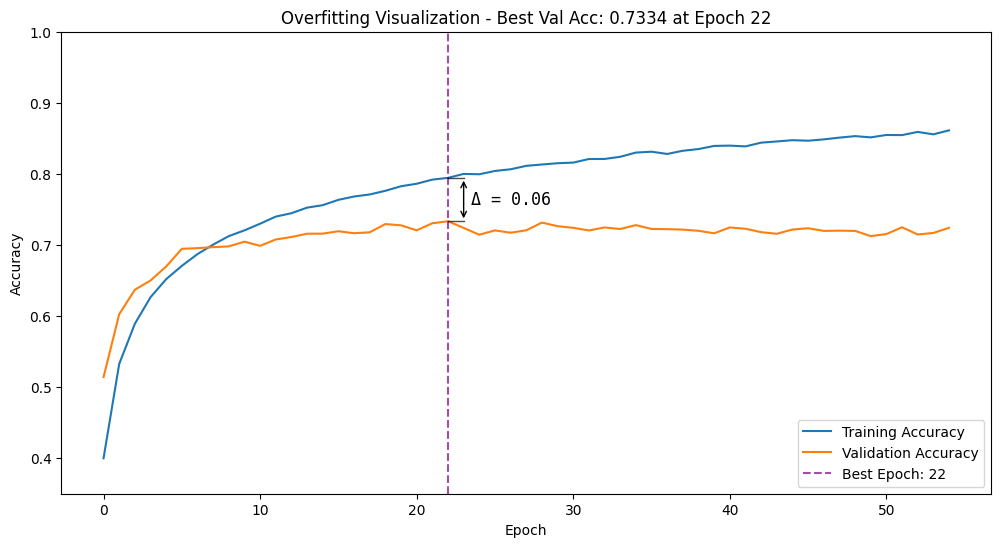

In [79]:
helpers.plot_overfitting(train_acc, val_acc)

let's try the second approach now: trying to lower the dropout value

In [57]:
d25_lower_dropout_cnn_model = models.Sequential(
    [
        # convolutional base
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        # classifier
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # dropout layer
        layers.Dropout(0.25),  # notice the dropout value here
        layers.Dense(10),
    ]
)

d25_lower_dropout_cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

d25_lower_dropout_history = d25_lower_dropout_cnn_model.fit(
    train_images,
    train_labels,
    epochs=25,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2787 - loss: 1.9281

I0000 00:00:1777364093.502742   13960 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3702 - loss: 1.7079 - val_accuracy: 0.4975 - val_loss: 1.4191
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5175 - loss: 1.3436 - val_accuracy: 0.5914 - val_loss: 1.1593
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5769 - loss: 1.1909 - val_accuracy: 0.6088 - val_loss: 1.0971
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6135 - loss: 1.0973 - val_accuracy: 0.6325 - val_loss: 1.0311
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6386 - loss: 1.0250 - val_accuracy: 0.6546 - val_loss: 0.9894
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6584 - loss: 0.9678 - val_accuracy: 0.6770 - val_loss: 0.9310
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6812 - loss: 0.8987 - val_accuracy: 0.6796 - val_loss: 0.9250
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6991 - loss: 0.8544 - val_accuracy: 0.6867 - val

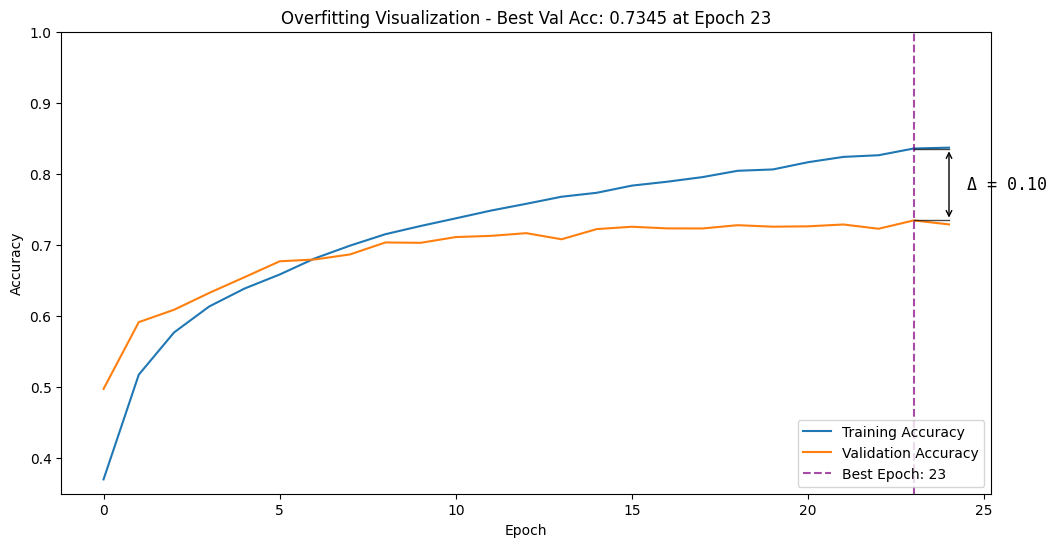

In [58]:
train_acc = d25_lower_dropout_history.history['accuracy']
val_acc = d25_lower_dropout_history.history['val_accuracy']

helpers.plot_overfitting(train_acc, val_acc)

we got mostly the same results as before (val_accuracy: 0.7 and overfitting about the same amount) with 10 less epochs. is that good? technically yeah, less time to train means faster prototyping but we're more interested in the results because in practice we train the model once. the goal is better results not faster results.

we could try and lower the dropout value even further...

sure, let's do that

In [59]:
d15_lower_dropout_cnn_model = models.Sequential(
    [
        # convolutional base
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        # classifier
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # dropout layer
        layers.Dropout(0.15),  # notice the dropout value here again
        layers.Dense(10),
    ]
)

d15_lower_dropout_cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

d15_lower_dropout_history = d15_lower_dropout_cnn_model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/30
 22/391 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1090 - loss: 2.3033

I0000 00:00:1777364175.316801   13960 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2589 - loss: 1.9848

I0000 00:00:1777364179.844935   13960 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3400 - loss: 1.7813 - val_accuracy: 0.4633 - val_loss: 1.4621
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4820 - loss: 1.4182 - val_accuracy: 0.5354 - val_loss: 1.2973
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5446 - loss: 1.2673 - val_accuracy: 0.5791 - val_loss: 1.1724
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5882 - loss: 1.1597 - val_accuracy: 0.6151 - val_loss: 1.0766
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6199 - loss: 1.0775 - val_accuracy: 0.6322 - val_loss: 1.0250
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6398 - loss: 1.0231 - val_accuracy: 0.6485 - val_loss: 0.9917
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6585 - loss: 0.9670 - val_accuracy: 0.6705 - val_loss: 0.9364
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6739 - loss: 0.9270 - val_accuracy: 0.6651 - val

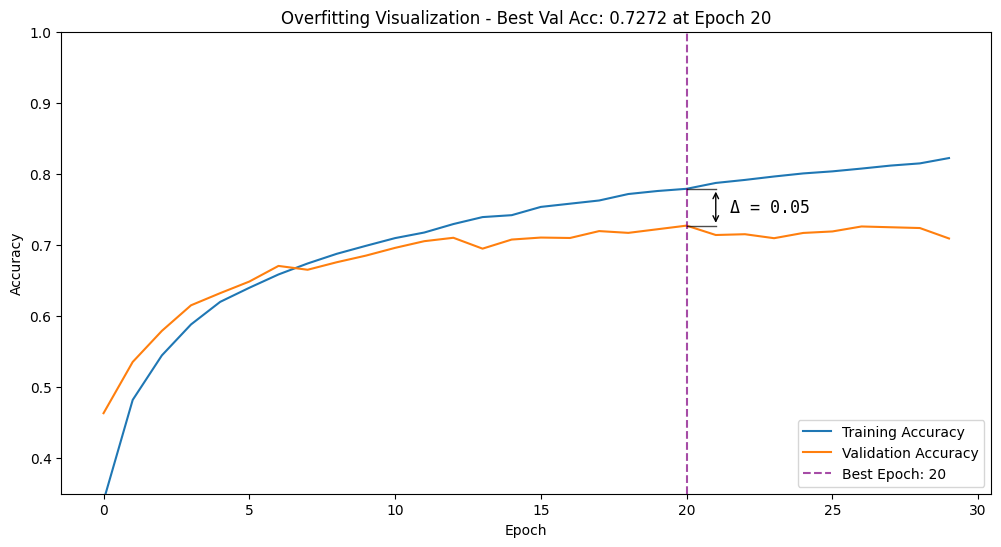

In [60]:
train_acc = d15_lower_dropout_history.history["accuracy"]
val_acc = d15_lower_dropout_history.history["val_accuracy"]

helpers.plot_overfitting(train_acc, val_acc)

mostly the same. ill assume we can't go any further with this approach alone. 

let's try something different

data augmentation can take many forms but in the case of images we simply mean to improve accuracy by giving the model more variantions of the same image it's seen a couple times before. 

why does this work?

because the model doesnt learn a cat is represented by that specific image itself but by the form of the cat, the edges, the shapes, the colors. it helps in generalizing better and if it's generalizing better we have less overfitting as a result.

and it's easier than you'd assume: we take the image and rotate around by factors of 90 degrees. that's 3 more images

then we flip it on its axis, horizontally and vertically. that's 3 * 2 * 2 (because each horizontal flip can also be flipped vertically too afterwards or not) 

and finally we can translate the image by an amount of pixels to all 4 directions. finally that would be 4 * 3 * 2 * 2 = 48 variations on each image. quite a lot of new data 

im shit at math so i might be wrong. let's instead see it with out eyes

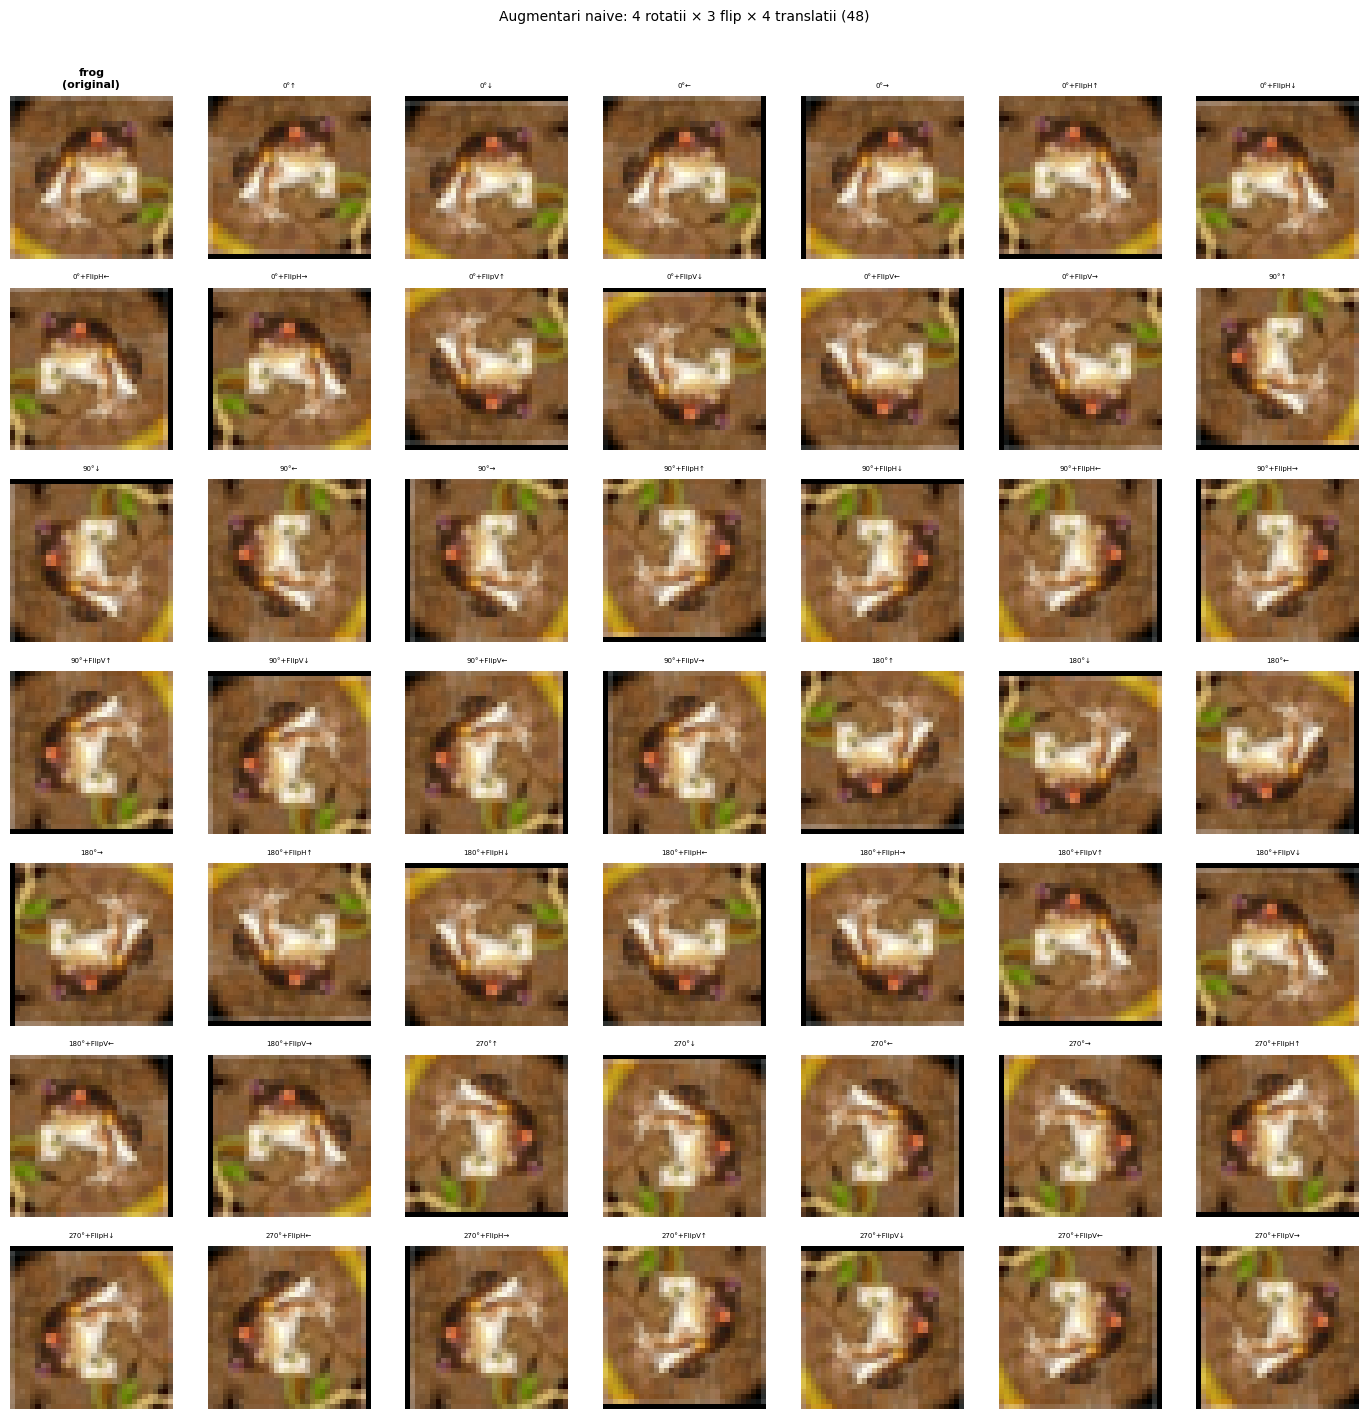

In [61]:
helpers.show_augmentations_bad(train_images[0], train_labels[0], class_names)

many frog

but wait- have you ever seen an upside down frog? unless the frog was dead i think not. im sorry.

so let's instead rotate the frog by maximum 10-20 degrees each side and only flip it horizontally

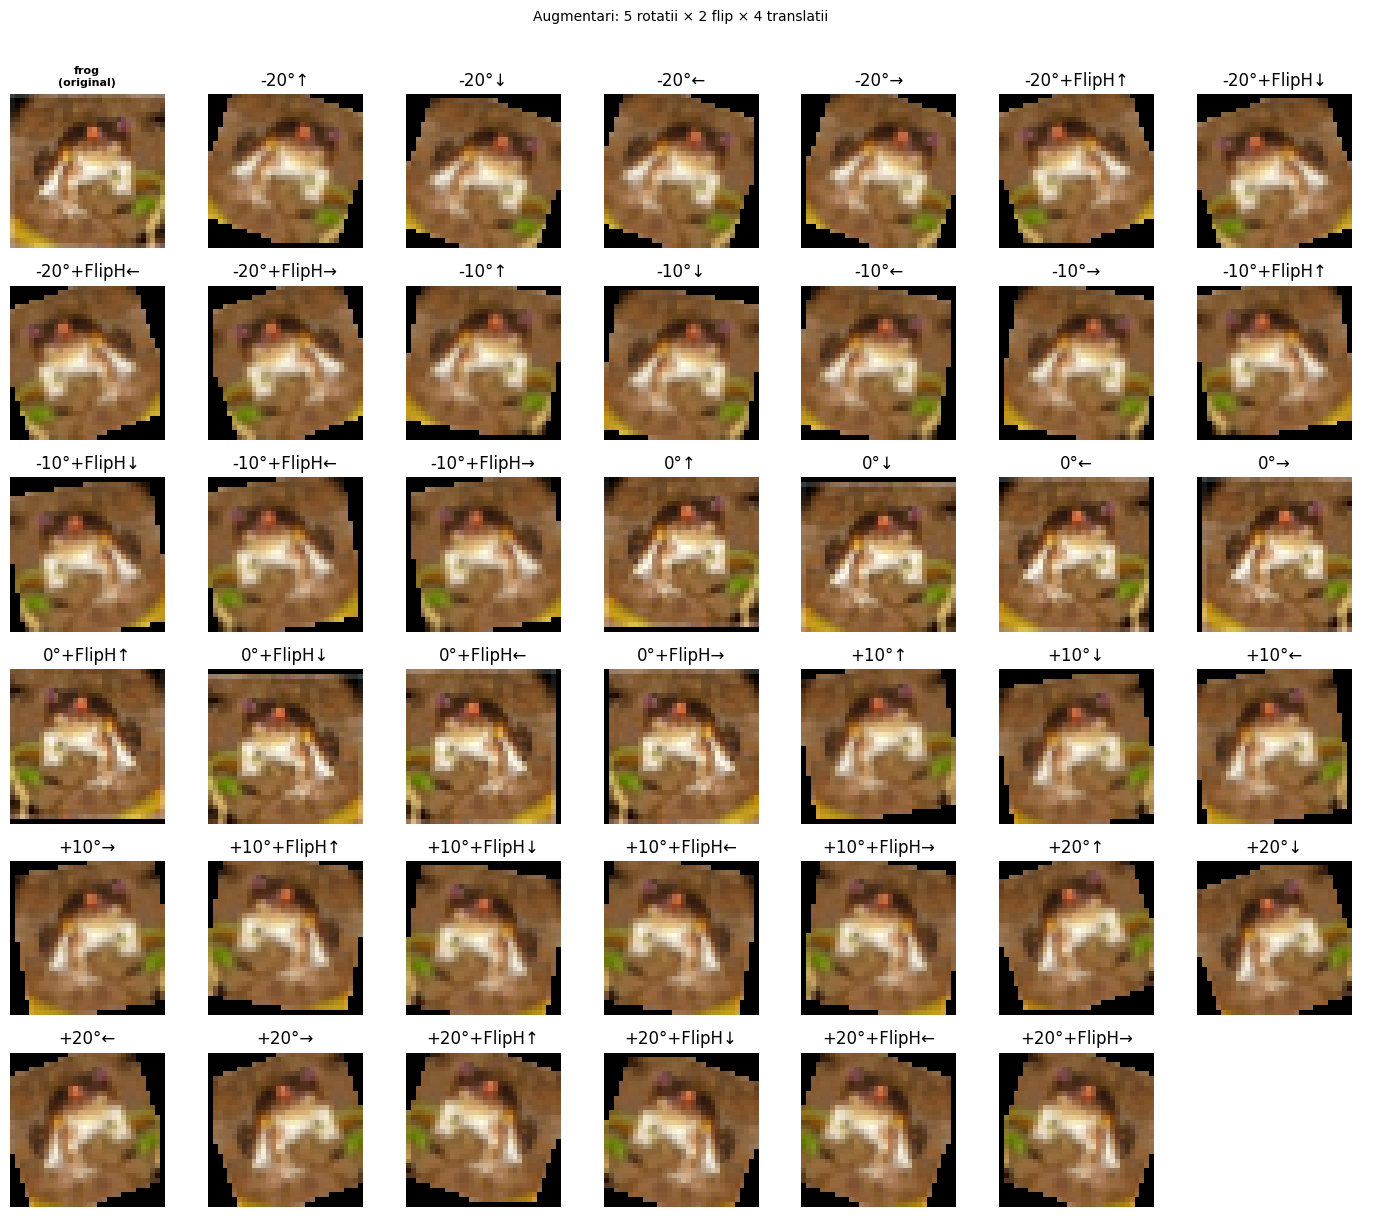

In [62]:
helpers.show_augmentations(train_images[0], train_labels[0], class_names)

this but for every image in the dataset. 

crazy amounts of new data. even though it's artificial data it does help with the biggest problem for the model right now: overfitting

let's try training a new model with this new technique

In [63]:
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

augmented_cnn_model = models.Sequential([
    # augmentation layer
    data_augmentation,
    
    # convolutional base
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(10)
])

augmented_cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

augmented_history = augmented_cnn_model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3009 - loss: 1.8787 - val_accuracy: 0.3628 - val_loss: 1.8313
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4002 - loss: 1.6358 - val_accuracy: 0.4987 - val_loss: 1.4115
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4420 - loss: 1.5350 - val_accuracy: 0.4932 - val_loss: 1.4037
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4736 - loss: 1.4572 - val_accuracy: 0.5102 - val_loss: 1.3719
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4985 - loss: 1.3989 - val_accuracy: 0.5264 - val_loss: 1.3276
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5153 - loss: 1.3511 - val_accuracy: 0.5506 - val_loss: 1.3014
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5281 - loss: 1.3155 - val_accuracy: 0.5874 - val_loss: 1.1588
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5430 - loss: 1.2841 - val_accu

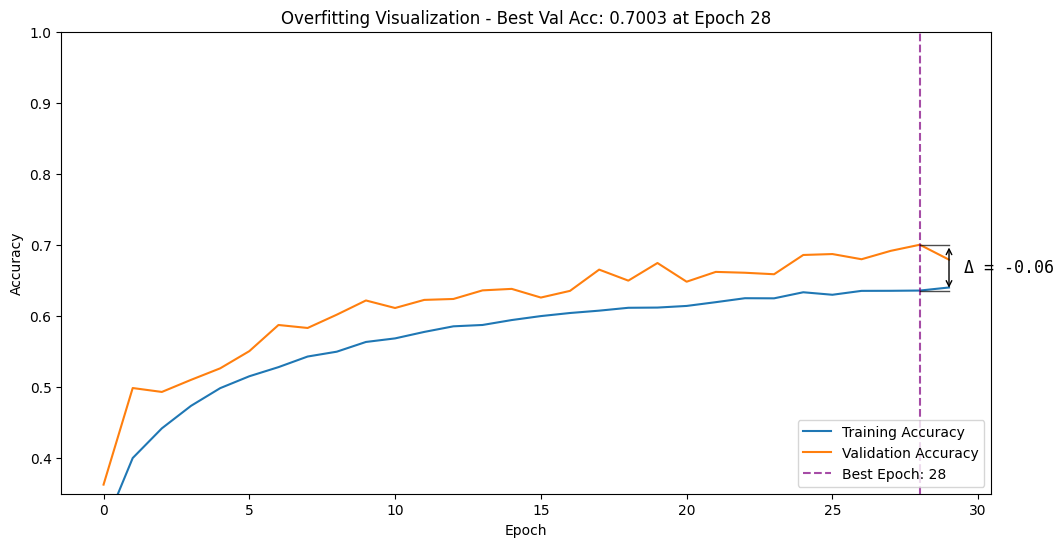

In [64]:
train_acc = augmented_history.history['accuracy']
val_acc = augmented_history.history['val_accuracy']
helpers.plot_overfitting(train_acc, val_acc)

interesting!

even though we've run it more than any other before it still didnt converge, it looks like it can keep going

In [65]:
augmented_history_run2 = augmented_cnn_model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6470 - loss: 1.0099 - val_accuracy: 0.6792 - val_loss: 0.9273
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6447 - loss: 1.0174 - val_accuracy: 0.6801 - val_loss: 0.9414
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6448 - loss: 1.0124 - val_accuracy: 0.6668 - val_loss: 0.9513
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6487 - loss: 1.0051 - val_accuracy: 0.6925 - val_loss: 0.8886
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6517 - loss: 0.9963 - val_accuracy: 0.6958 - val_loss: 0.8786
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6543 - loss: 0.9876 - val_accuracy: 0.6893 - val_loss: 0.8886
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6548 - loss: 0.9840 - val_accuracy: 0.6866 - val_loss: 0.9373
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6578 - loss: 0.9764 - val_accu

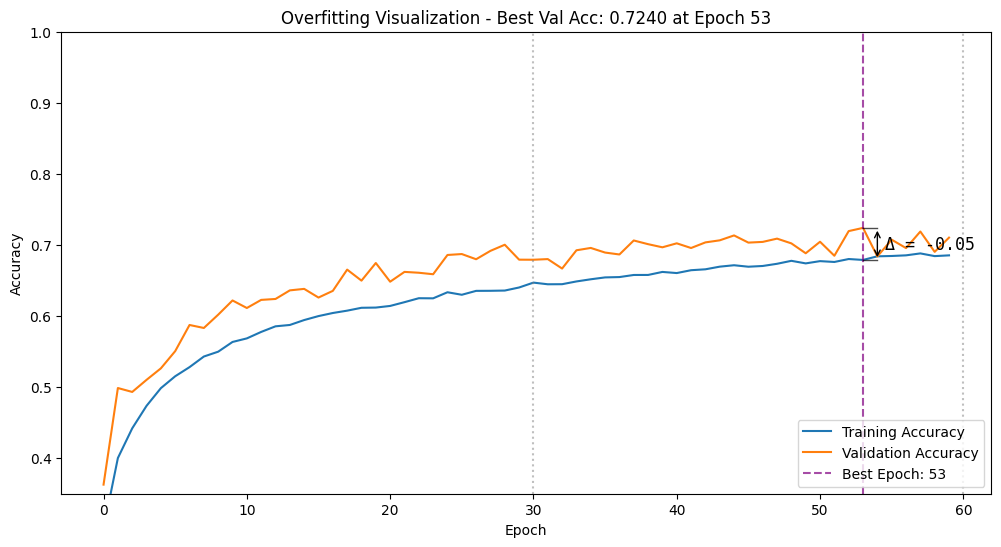

In [66]:
train_acc = augmented_history.history['accuracy'] + augmented_history_run2.history['accuracy']
val_acc = augmented_history.history['val_accuracy'] + augmented_history_run2.history['val_accuracy']
helpers.plot_overfitting(train_acc, val_acc, epochs=[30, 60])

In [67]:
augmented_history_run3 = augmented_cnn_model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6847 - loss: 0.9036 - val_accuracy: 0.7163 - val_loss: 0.8251
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6881 - loss: 0.8950 - val_accuracy: 0.6993 - val_loss: 0.8907
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6904 - loss: 0.8916 - val_accuracy: 0.6917 - val_loss: 0.9292
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6889 - loss: 0.8896 - val_accuracy: 0.7113 - val_loss: 0.8407
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6887 - loss: 0.8891 - val_accuracy: 0.6954 - val_loss: 0.9310
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6924 - loss: 0.8899 - val_accuracy: 0.7138 - val_loss: 0.8225
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6942 - loss: 0.8826 - val_accuracy: 0.7157 - val_loss: 0.8185
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6929 - loss: 0.8903 - val_accu

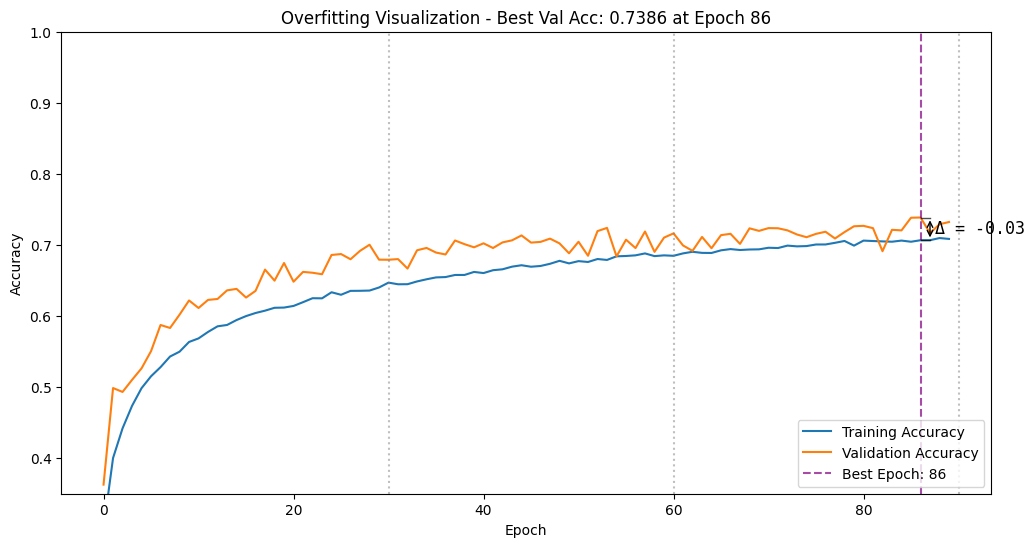

In [68]:
train_acc = augmented_history.history['accuracy'] + augmented_history_run2.history['accuracy'] + augmented_history_run3.history['accuracy']
val_acc = augmented_history.history['val_accuracy'] + augmented_history_run2.history['val_accuracy'] + augmented_history_run3.history['val_accuracy']
helpers.plot_overfitting(train_acc, val_acc, epochs=[30, 60, 90])

i think this is the best we've seen so far. yippie!

let's see the confusion matrix you all know and love 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    airplane       0.72      0.81      0.76      1000
  automobile       0.81      0.91      0.86      1000
        bird       0.79      0.53      0.63      1000
         cat       0.66      0.48      0.55      1000
        deer       0.79      0.59      0.67      1000
         dog       0.69      0.66      0.68      1000
        frog       0.73      0.85      0.79      1000
       horse       0.65      0.88      0.74      1000
        ship       0.90      0.74      0.82      1000
       truck       0.67      0.88      0.76      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



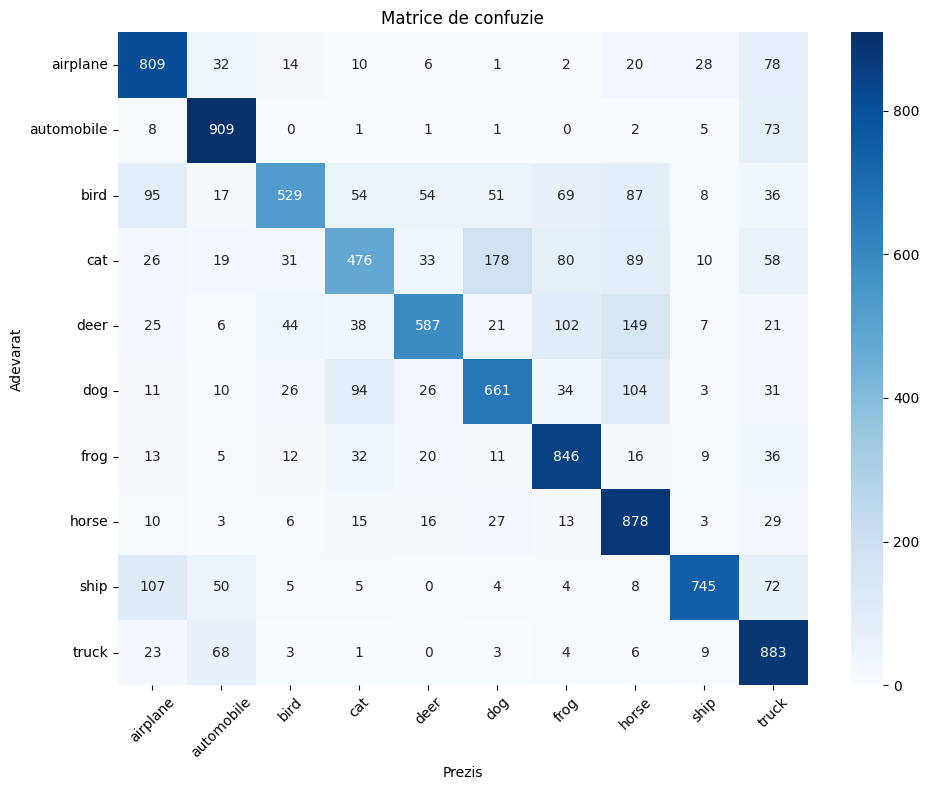

In [69]:
helpers.plot_confusion_matrix(augmented_cnn_model, test_images, test_labels, class_names)

Naive                      acc=0.7137  loss=0.8380
Dropout                    acc=0.7126  loss=1.0540
Augmentation               acc=0.7323  loss=0.7848


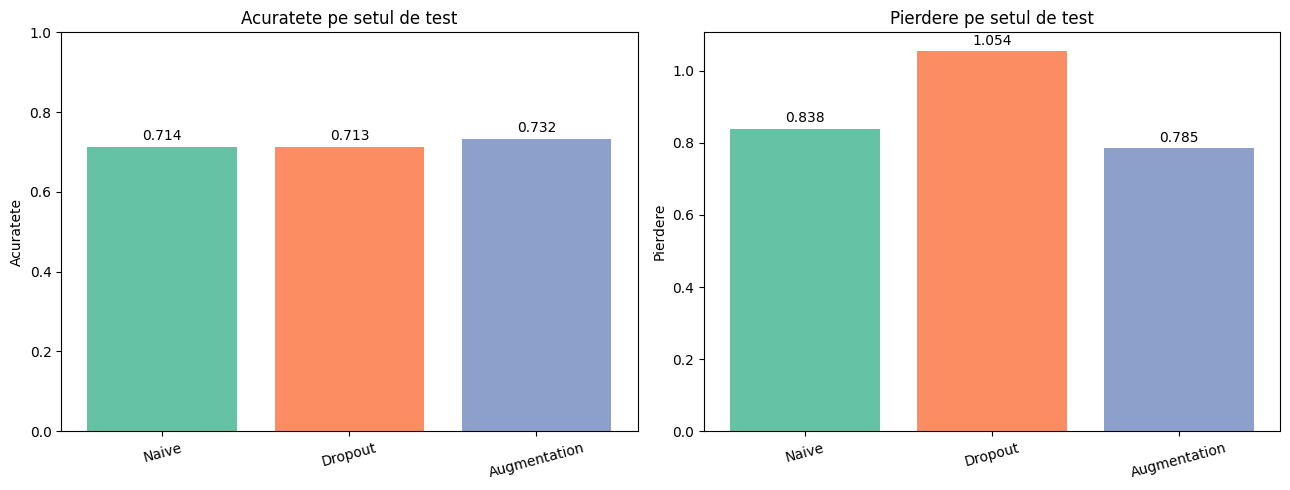

In [70]:
helpers.compare_models({
    "Naive": naive_cnn_model,
    "Dropout": dropout_cnn_model,
    "Augmentation": augmented_cnn_model,
}, test_images, test_labels)

### 🤌 Final Conclusion: The Power of CNNs

Traditional neural networks fail with images because they force 2D pictures into 1D lines, destroying spatial structure and requiring an impossible number of parameters. **Convolutional Neural Networks (CNNs)** solve this by looking at images exactly the way human eyes do.



**CNNs summed up:**
> *"A CNN is a specialized neural network designed for image processing. Instead of looking at every pixel at once, it uses sliding filters to scan the image for specific features, sharing parameters to save computing power. It then shrinks the data down to just the most important patterns before handing it off to a standard neural network to make a final classification."*

**The Core Pipeline:**
1. 📥 **Input:** A 3D tensor (Height, Width, RGB Colors).
2. 🕵️‍♂️ **Conv2D (The Detective):** Scans the image with small 2D filters to extract features (edges, textures, colors).
3. 🗜️ **MaxPooling2D (The Summarizer):** Shrinks the image grid, keeping only the loudest features to save memory.
4. 🥞 **Flatten (The Unroller):** Converts the final 3D block of features into a single 1D straight line.
5. ⚖️ **Dense Layers (The Judge):** Uses the unrolled evidence and outputs the final prediction.

**The Golden Rule of Training:**
A model that just memorizes the training data is useless in the real world (Overfitting). True success in machine learning isn't just about building the architecture; it's about using tools like **Dropout** to force the network to learn genuine, generalized patterns, and using **Confusion Matrices** to deeply understand its blind spots.